# 🔵 K-Means Clustering: A Complete Study Guide
### Using Python & Scikit-Learn

---

## 📌 Introduction

**K-Means Clustering** is one of the most popular and widely used **unsupervised machine learning algorithms**. It is used to group (cluster) similar data points together based on their features — without requiring any labelled data.

### How Does It Work?

The algorithm works in the following steps:

1. **Choose K** — decide how many clusters you want.
2. **Initialize Centroids** — randomly place K centroids in the feature space.
3. **Assign Points** — assign each data point to the nearest centroid.
4. **Update Centroids** — recalculate centroids as the mean of all points in each cluster.
5. **Repeat** — continue steps 3–4 until centroids no longer change (convergence).

> 💡 **Key Insight:** K-Means is an **unsupervised** algorithm — it finds hidden structure in data **without labels**. It's ideal for tasks like customer segmentation, image compression, document clustering, and anomaly detection.

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- ✅ Understand how the K-Means Clustering algorithm works step by step
- ✅ Implement K-Means using **Scikit-Learn** in Python
- ✅ Generate and visualise synthetic datasets for clustering experiments
- ✅ Interpret key model outputs: **cluster labels**, **centroids**, **inertia**, and **iterations**
- ✅ Use the **Elbow Method** to choose the optimal number of clusters (K)
- ✅ Evaluate clustering quality using the **Silhouette Score**
- ✅ Compare clustering results across different values of K
- ✅ Apply K-Means to a real-world **Customer Segmentation** problem
- ✅ Understand the **advantages and limitations** of K-Means

---

## 📦 Section 1: Import Required Libraries

Before we begin, we import all the tools we'll need:

| Library | Purpose |
|---|---|
| `numpy` | Numerical operations and array handling |
| `pandas` | Data manipulation and tabular data |
| `matplotlib` | Plotting and visualisation |
| `sklearn.datasets` | Generating synthetic datasets |
| `sklearn.cluster` | K-Means algorithm implementation |
| `sklearn.metrics` | Evaluation metrics (e.g., silhouette score) |
| `sklearn.preprocessing` | Feature scaling / standardisation |

In [1]:
# --- Import Required Libraries ---

import numpy as np                          # Numerical computing
import pandas as pd                         # Data manipulation
import matplotlib.pyplot as plt             # Plotting
import matplotlib.cm as cm                  # Colour maps for plots

from sklearn.datasets import make_blobs     # Synthetic dataset generator
from sklearn.cluster import KMeans          # K-Means algorithm
from sklearn.metrics import silhouette_score  # Cluster quality metric
from sklearn.preprocessing import StandardScaler  # Feature standardisation

import warnings
warnings.filterwarnings('ignore')           # Suppress minor warnings

# Set a consistent plot style
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🔢 Section 2: Generate a Synthetic Dataset

We use **`make_blobs`** from Scikit-Learn to create a controlled synthetic dataset. This is perfect for learning because we *know* the true cluster structure.

### Parameters Explained:

| Parameter | Value | Meaning |
|---|---|---|
| `n_samples` | 300 | Total number of data points |
| `centers` | 3 | Number of distinct blob centres (true clusters) |
| `cluster_std` | 0.8 | Standard deviation (spread) of each cluster |
| `random_state` | 42 | Seed for reproducibility |

> **Note:** In real-world scenarios, we don't know the true clusters — that's exactly what K-Means helps us discover!

In [2]:
# --- Generate Synthetic Dataset ---

# make_blobs creates isotropic Gaussian blobs for clustering
X, y_true = make_blobs(
    n_samples=300,       # 300 data points
    centers=3,           # 3 true cluster centres
    cluster_std=0.8,     # Moderate spread — not too tight, not too loose
    random_state=42      # Fixed seed for reproducibility
)

# Convert to a DataFrame for easy inspection
df = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])
df['True Label'] = y_true

# Display basic information
print(f"Dataset shape  : {X.shape}")
print(f"Feature columns: {list(df.columns[:2])}")
print(f"True clusters  : {np.unique(y_true)}")
print("\n📋 First 5 rows:")
print(df.head())

Dataset shape  : (300, 2)
Feature columns: ['Feature 1', 'Feature 2']
True clusters  : [0 1 2]

📋 First 5 rows:
   Feature 1  Feature 2  True Label
0  -7.247116  -7.559985           2
1  -7.567958  -7.187754           2
2  -1.851162   8.037611           0
3   4.465734   2.852191           1
4  -8.510127  -7.686579           2


## 📊 Section 3: Visualise the Original Dataset

Before applying any algorithm, it's best practice to **explore and visualise your data**. A scatter plot helps us:

- Understand the overall distribution of data points
- Spot potential clusters visually
- Identify outliers or unusual patterns

> In real problems, we would plot the data **without** colour labels — since we don't know the ground truth. Here, we colour by true labels for illustration purposes.

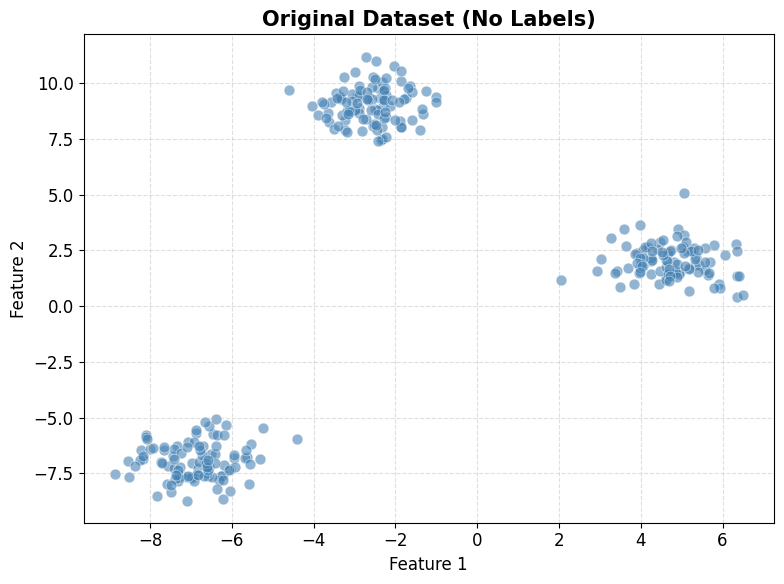

👆 Can you spot the 3 natural clusters by eye?


In [3]:
# --- Visualise the Original Dataset ---

plt.figure(figsize=(8, 6))

# Plot without labels to simulate a real unsupervised scenario
plt.scatter(
    X[:, 0], X[:, 1],
    c='steelblue',
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5,
    s=60
)

plt.title('Original Dataset (No Labels)', fontsize=15, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("👆 Can you spot the 3 natural clusters by eye?")

## ⚙️ Section 4: Apply K-Means Clustering

Now we apply the **K-Means algorithm** using Scikit-Learn's `KMeans` class.

### Key Parameters:

| Parameter | Value | Meaning |
|---|---|---|
| `n_clusters` | 3 | Number of clusters to form |
| `init` | `'k-means++'` | Smart centroid initialisation (avoids poor starts) |
| `n_init` | 10 | Run algorithm 10 times with different seeds; keep best |
| `max_iter` | 300 | Max iterations per single run |
| `random_state` | 42 | Ensures reproducibility |

### Why K-Means++?
Standard K-Means initialises centroids randomly, which can lead to poor clustering. **K-Means++** spreads the initial centroids far apart, dramatically improving both speed and quality.

In [4]:
# --- Apply K-Means Clustering ---

# Create the KMeans model
kmeans = KMeans(
    n_clusters=3,         # We expect 3 clusters
    init='k-means++',     # Smart initialisation strategy
    n_init=10,            # Run 10 times, keep best result
    max_iter=300,         # Maximum iterations per run
    random_state=42       # Fix seed for reproducible results
)

# Fit the model to the data
kmeans.fit(X)

print("✅ K-Means model fitted successfully!")
print(f"   Model converged in {kmeans.n_iter_} iterations.")

✅ K-Means model fitted successfully!
   Model converged in 2 iterations.


## 📋 Section 5: Retrieve Model Outputs

After fitting K-Means, we can extract several important attributes:

| Attribute | Description |
|---|---|
| `labels_` | Cluster assignment (0, 1, 2, …) for each data point |
| `cluster_centers_` | Coordinates of each cluster centroid |
| `inertia_` | Within-Cluster Sum of Squares (WCSS) — lower is better |
| `n_iter_` | Number of iterations until convergence |

In [5]:
# --- Retrieve Model Outputs ---

# 1. Cluster labels assigned to each data point
labels = kmeans.labels_
print("🏷️  Cluster Labels (first 20):", labels[:20])
print(f"   Unique clusters: {np.unique(labels)}")

# 2. Coordinates of each cluster centroid
centers = kmeans.cluster_centers_
print("\n📍 Cluster Centroids:")
for i, center in enumerate(centers):
    print(f"   Cluster {i}: ({center[0]:.3f}, {center[1]:.3f})")

# 3. Inertia — sum of squared distances of points to their cluster centre
inertia = kmeans.inertia_
print(f"\n📉 Inertia (WCSS): {inertia:.4f}")
print("   (Lower inertia = tighter, more compact clusters)")

# 4. Number of iterations to converge
print(f"\n🔄 Iterations to Converge: {kmeans.n_iter_}")

🏷️  Cluster Labels (first 20): [1 1 0 2 1 2 0 2 0 0 0 2 0 0 1 0 1 2 0 0]
   Unique clusters: [0 1 2]

📍 Cluster Centroids:
   Cluster 0: (-2.608, 9.038)
   Cluster 1: (-6.883, -6.963)
   Cluster 2: (4.726, 2.003)

📉 Inertia (WCSS): 362.7901
   (Lower inertia = tighter, more compact clusters)

🔄 Iterations to Converge: 2


## 🎨 Section 6: Visualise Clustered Data

Now let's visualise the results of our clustering. We will:
- **Colour** each data point according to its assigned cluster
- **Mark centroids** with a distinct symbol (⭐) so they stand out clearly

This plot lets us visually verify how well K-Means separated the data.

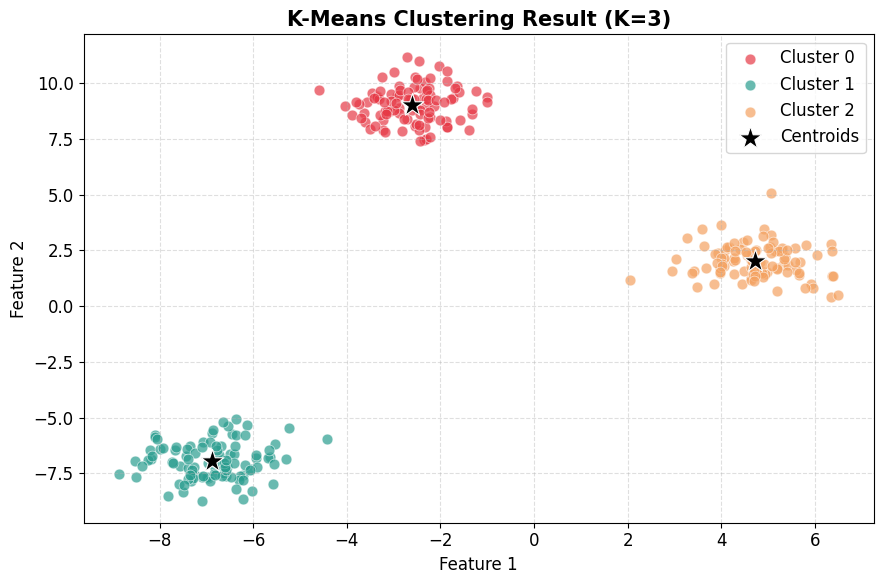

📊 Points per cluster:
   Cluster 0: 100 points
   Cluster 1: 100 points
   Cluster 2: 100 points


In [6]:
# --- Visualise Clustered Data ---

# Define distinct colours for each cluster
colours = ['#E63946', '#2A9D8F', '#F4A261']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.figure(figsize=(9, 6))

# Plot each cluster with a different colour
for i in range(3):
    mask = labels == i  # Boolean mask for cluster i
    plt.scatter(
        X[mask, 0], X[mask, 1],
        c=colours[i],
        label=cluster_names[i],
        alpha=0.7,
        edgecolors='white',
        linewidth=0.5,
        s=60
    )

# Plot centroids with a star marker
plt.scatter(
    centers[:, 0], centers[:, 1],
    c='black',
    marker='*',
    s=300,
    label='Centroids',
    zorder=5,
    edgecolors='white',
    linewidth=0.8
)

plt.title('K-Means Clustering Result (K=3)', fontsize=15, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Count data points per cluster
unique, counts = np.unique(labels, return_counts=True)
print("📊 Points per cluster:")
for u, c in zip(unique, counts):
    print(f"   Cluster {u}: {c} points")

## 📐 Section 7: Elbow Method for Choosing K

One of the biggest challenges in K-Means is choosing the right value of **K** (number of clusters). The **Elbow Method** helps us find a good K by:

1. Running K-Means for different values of K (e.g., K = 1 to 10)
2. Recording the **inertia** (WCSS — Within-Cluster Sum of Squares) for each K
3. Plotting inertia vs. K
4. Looking for the **"elbow point"** — where the rate of decrease sharply levels off

### How to Identify the Elbow:
- As K increases, inertia always decreases (more clusters = tighter fit)
- But beyond a certain K, the improvement becomes **marginal**
- The **elbow point** is where the curve bends — that's your optimal K

> ⚠️ The elbow is sometimes ambiguous. When in doubt, use it together with the Silhouette Score (see next section).

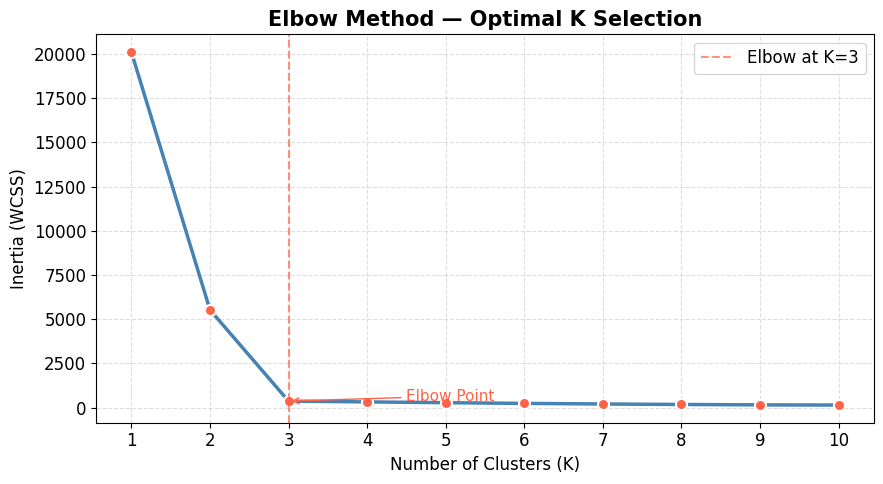

📉 WCSS Values:
   K= 1: 20120.54
   K= 2: 5526.51
   K= 3: 362.79
   K= 4: 318.07
   K= 5: 273.36
   K= 6: 233.60
   K= 7: 200.97
   K= 8: 172.85
   K= 9: 149.96
   K=10: 139.27


In [7]:
# --- Elbow Method ---

wcss = []  # List to store inertia (WCSS) for each K
k_range = range(1, 11)  # Test K from 1 to 10

for k in k_range:
    model = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    model.fit(X)
    wcss.append(model.inertia_)  # Store inertia for this K

# Plot the Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, marker='o', color='steelblue', linewidth=2.5,
         markersize=8, markerfacecolor='tomato', markeredgecolor='white', markeredgewidth=1.5)

# Annotate the likely elbow point
plt.axvline(x=3, color='tomato', linestyle='--', alpha=0.7, label='Elbow at K=3')
plt.annotate('Elbow Point', xy=(3, wcss[2]), xytext=(4.5, wcss[2]+30),
             arrowprops=dict(arrowstyle='->', color='tomato'), fontsize=11, color='tomato')

plt.title('Elbow Method — Optimal K Selection', fontsize=15, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Print the WCSS values
print("📉 WCSS Values:")
for k, w in zip(k_range, wcss):
    print(f"   K={k:2d}: {w:.2f}")

## 📏 Section 8: Silhouette Score Analysis

The **Silhouette Score** is a more robust way to evaluate clustering quality. It measures how similar a point is to its own cluster compared to other clusters.

### Formula:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Where:
- **a(i)** = average distance from point *i* to all other points **in its own cluster** (cohesion)
- **b(i)** = average distance from point *i* to all points in the **nearest other cluster** (separation)

### Interpretation:

| Score Range | Meaning |
|---|---|
| Close to **+1** | Point is well-matched to its cluster ✅ |
| Around **0** | Point is on or near a cluster boundary ⚠️ |
| Close to **-1** | Point may have been assigned to the wrong cluster ❌ |

> **Goal:** Maximise the average silhouette score to find the best K.

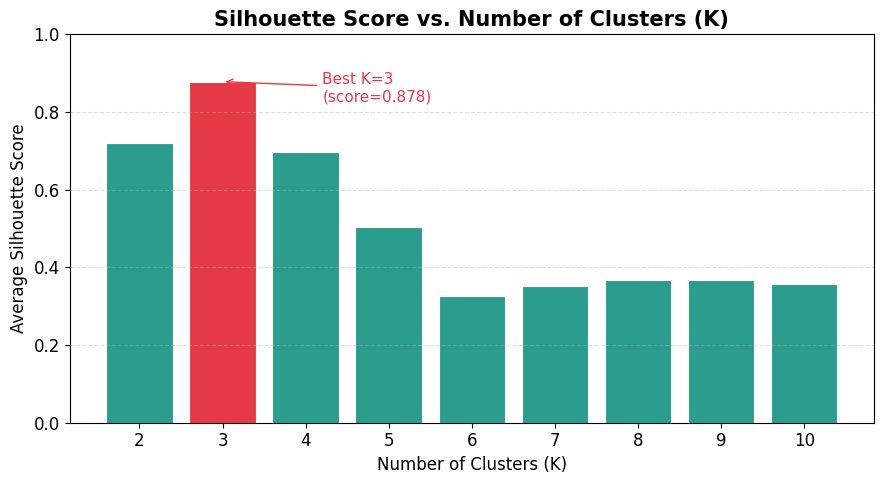

📊 Silhouette Scores:
   K= 2: 0.7206
   K= 3: 0.8781 ⬅ BEST
   K= 4: 0.6974
   K= 5: 0.5026
   K= 6: 0.3268
   K= 7: 0.3508
   K= 8: 0.3666
   K= 9: 0.3686
   K=10: 0.3568

🏆 Best K based on Silhouette Score: K = 3 (score = 0.8781)


In [8]:
# --- Silhouette Score Analysis ---

silhouette_scores = []    # Store silhouette scores
k_range_sil = range(2, 11)  # Silhouette requires at least 2 clusters

for k in k_range_sil:
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    preds = model.fit_predict(X)  # Fit and predict cluster labels
    score = silhouette_score(X, preds)  # Calculate mean silhouette score
    silhouette_scores.append(score)

# Find the best K
best_k = k_range_sil[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

# Plot Silhouette Scores
plt.figure(figsize=(9, 5))
bar_colours = ['#2A9D8F' if k != best_k else '#E63946' for k in k_range_sil]
bars = plt.bar(k_range_sil, silhouette_scores, color=bar_colours, edgecolor='white', linewidth=0.8)

# Annotate best K
plt.annotate(f'Best K={best_k}\n(score={best_score:.3f})',
             xy=(best_k, best_score), xytext=(best_k + 1.2, best_score - 0.05),
             arrowprops=dict(arrowstyle='->', color='#E63946'), fontsize=11, color='#E63946')

plt.title('Silhouette Score vs. Number of Clusters (K)', fontsize=15, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range_sil)
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()

# Print scores
print("📊 Silhouette Scores:")
for k, s in zip(k_range_sil, silhouette_scores):
    marker = " ⬅ BEST" if k == best_k else ""
    print(f"   K={k:2d}: {s:.4f}{marker}")

print(f"\n🏆 Best K based on Silhouette Score: K = {best_k} (score = {best_score:.4f})")

## 🔍 Section 9: Compare Different Values of K

Let's visually compare how the clustering results look for **K = 2, 3, 4, and 5**. This side-by-side comparison helps you:

- See how clusters split as K increases
- Understand why choosing the right K matters
- Develop intuition for what "good" clustering looks like vs. over-segmentation

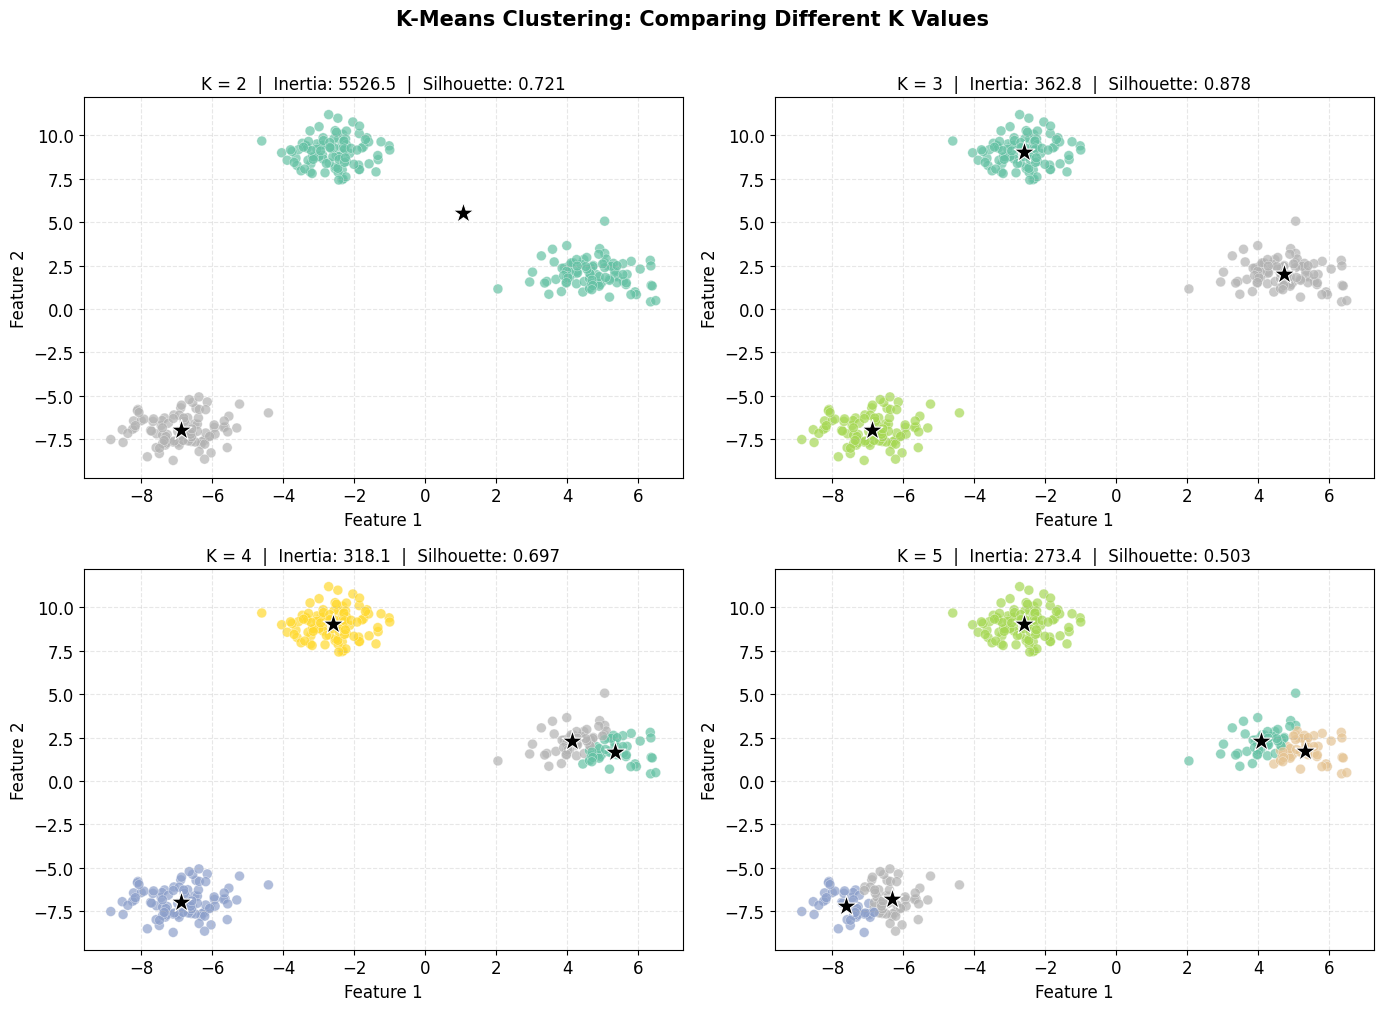

💡 Observation: K=3 matches our true data structure best.
   K=2 under-clusters; K=4 and K=5 split natural groups unnecessarily.


In [9]:
# --- Compare Different Values of K ---

k_values = [2, 3, 4, 5]  # K values to compare
cmap = plt.cm.Set2          # Colour map for clusters

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Flatten 2x2 grid for easy iteration

for idx, k in enumerate(k_values):
    ax = axes[idx]

    # Fit K-Means for this K
    model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    lbls = model.fit_predict(X)
    ctrs = model.cluster_centers_

    # Compute silhouette score for this K
    sil = silhouette_score(X, lbls) if k > 1 else None

    # Plot data points coloured by cluster
    scatter = ax.scatter(X[:, 0], X[:, 1], c=lbls, cmap=cmap,
                         alpha=0.7, s=50, edgecolors='white', linewidth=0.3)

    # Plot centroids
    ax.scatter(ctrs[:, 0], ctrs[:, 1], c='black', marker='*',
               s=250, zorder=5, edgecolors='white', linewidth=0.8)

    sil_text = f"  |  Silhouette: {sil:.3f}" if sil else ""
    ax.set_title(f'K = {k}  |  Inertia: {model.inertia_:.1f}{sil_text}', fontsize=12)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('K-Means Clustering: Comparing Different K Values', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("💡 Observation: K=3 matches our true data structure best.")
print("   K=2 under-clusters; K=4 and K=5 split natural groups unnecessarily.")

## 🛍️ Section 10: Real-World Example — Customer Segmentation

Let's apply K-Means to a classic real-world problem: **Customer Segmentation**.

### The Scenario:
A retail store has collected data on its customers. We want to group customers into meaningful segments based on:
- **Annual Income** (in $000s)
- **Spending Score** (1–100, assigned by the store based on purchase behaviour)

### Why Standardise?
Before clustering, we **standardise** (scale) the features using `StandardScaler`. This is important because:
- Features with larger numeric ranges can dominate the distance calculation
- Standardising ensures all features contribute equally

> This dataset is inspired by the well-known **Mall Customer Segmentation** dataset.

In [10]:
# --- Real-World Example: Customer Segmentation ---

# Step 1: Create a sample customer dataset
np.random.seed(42)

customer_data = pd.DataFrame({
    'CustomerID': range(1, 101),
    'Annual Income (k$)': np.concatenate([
        np.random.normal(20, 5, 20),    # Low income group
        np.random.normal(60, 8, 35),    # Mid income group
        np.random.normal(100, 10, 25),  # High income group
        np.random.normal(45, 5, 20)     # Mid-low mixed group
    ]),
    'Spending Score (1-100)': np.concatenate([
        np.random.normal(80, 8, 20),    # High spenders
        np.random.normal(50, 10, 35),   # Average spenders
        np.random.normal(20, 6, 25),    # Low spenders
        np.random.normal(60, 8, 20)     # Moderate spenders
    ])
})

# Clip values to realistic ranges
customer_data['Annual Income (k$)'] = customer_data['Annual Income (k$)'].clip(10, 140)
customer_data['Spending Score (1-100)'] = customer_data['Spending Score (1-100)'].clip(1, 100)

print("📋 Customer Dataset Preview:")
print(customer_data.head(8))
print(f"\nDataset shape: {customer_data.shape}")
print("\n📊 Summary Statistics:")
print(customer_data[['Annual Income (k$)', 'Spending Score (1-100)']].describe().round(2))

📋 Customer Dataset Preview:
   CustomerID  Annual Income (k$)  Spending Score (1-100)
0           1           22.483571               68.677034
1           2           19.308678               76.634837
2           3           23.238443               77.258284
3           4           27.615149               73.581782
4           5           18.829233               78.709714
5           6           18.829315               83.232407
6           7           27.896064               95.089487
7           8           23.837174               81.396623

Dataset shape: (100, 3)

📊 Summary Statistics:
       Annual Income (k$)  Spending Score (1-100)
count              100.00                  100.00
mean                58.30                   50.47
std                 28.99                   21.44
min                 10.43                   12.85
25%                 42.47                   34.35
50%                 54.89                   52.55
75%                 74.06                   64.18
ma

In [11]:
# --- Step 2: Standardise Features ---

# Extract the two features for clustering
X_customers = customer_data[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Standardise: mean=0, std=1 for each feature
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_customers)

print("Before Scaling:")
print(f"  Income   — Mean: {X_customers[:,0].mean():.2f}, Std: {X_customers[:,0].std():.2f}")
print(f"  Spending — Mean: {X_customers[:,1].mean():.2f}, Std: {X_customers[:,1].std():.2f}")

print("\nAfter Scaling:")
print(f"  Income   — Mean: {X_scaled[:,0].mean():.4f}, Std: {X_scaled[:,0].std():.4f}")
print(f"  Spending — Mean: {X_scaled[:,1].mean():.4f}, Std: {X_scaled[:,1].std():.4f}")
print("\n✅ Features standardised — ready for clustering!")

Before Scaling:
  Income   — Mean: 58.30, Std: 28.84
  Spending — Mean: 50.47, Std: 21.33

After Scaling:
  Income   — Mean: -0.0000, Std: 1.0000
  Spending — Mean: -0.0000, Std: 1.0000

✅ Features standardised — ready for clustering!


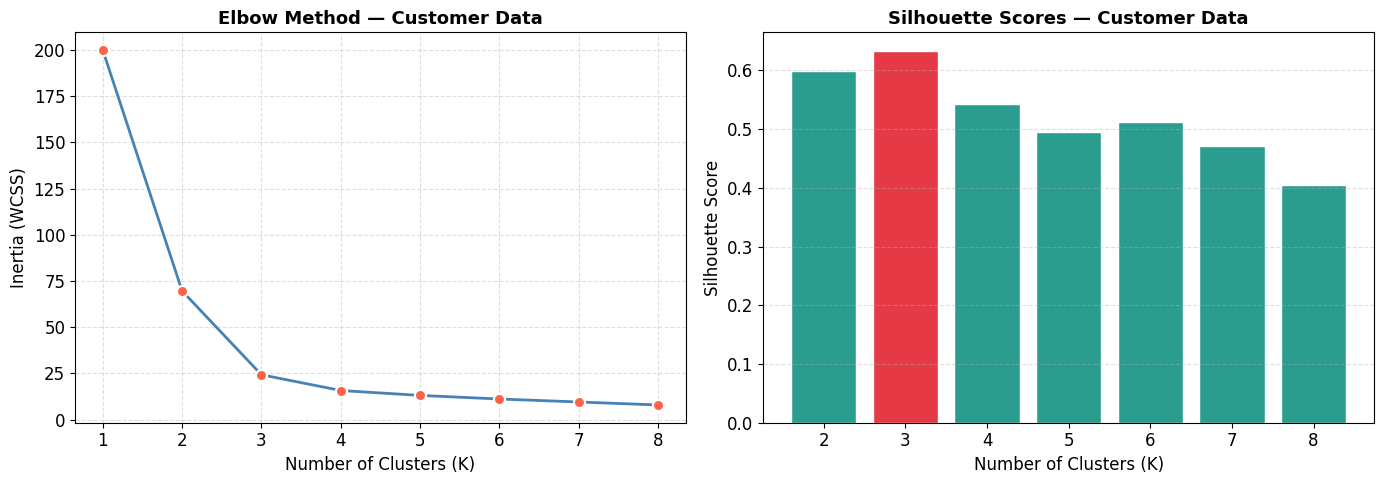

🏆 Best K for customer segmentation: K = 3


In [12]:
# --- Step 3: Find Optimal K Using Elbow + Silhouette ---

wcss_cust = []
sil_cust = []
k_test = range(2, 9)

for k in range(1, 9):
    m = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    m.fit(X_scaled)
    wcss_cust.append(m.inertia_)

for k in k_test:
    m = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    preds = m.fit_predict(X_scaled)
    sil_cust.append(silhouette_score(X_scaled, preds))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(range(1, 9), wcss_cust, marker='o', color='steelblue', linewidth=2,
         markersize=8, markerfacecolor='tomato', markeredgecolor='white', markeredgewidth=1.5)
ax1.set_title('Elbow Method — Customer Data', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.grid(True, linestyle='--', alpha=0.4)

# Silhouette plot
best_cust_k = list(k_test)[np.argmax(sil_cust)]
bar_c = ['#E63946' if k == best_cust_k else '#2A9D8F' for k in k_test]
ax2.bar(k_test, sil_cust, color=bar_c, edgecolor='white')
ax2.set_title('Silhouette Scores — Customer Data', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()
print(f"🏆 Best K for customer segmentation: K = {best_cust_k}")

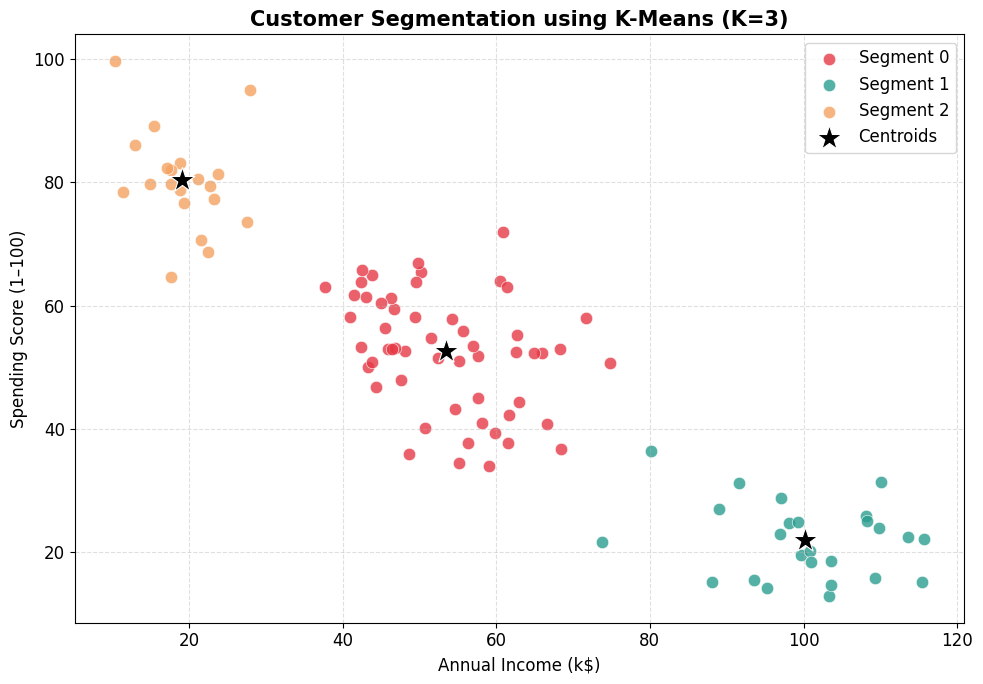


📊 Segment Summary (original scale):
         Avg Income (k$)  Avg Spending Score  Count
Segment                                            
0                  53.49               52.59     55
1                 100.18               21.90     25
2                  19.14               80.35     20


In [13]:
# --- Step 4: Apply K-Means and Visualise Customer Segments ---

# Fit final model on standardised data
kmeans_cust = KMeans(n_clusters=best_cust_k, init='k-means++', n_init=10, random_state=42)
cust_labels = kmeans_cust.fit_predict(X_scaled)

# Add cluster labels to the original (unscaled) dataframe for plotting
customer_data['Segment'] = cust_labels

# Get centroids in original scale
cust_centers_scaled = kmeans_cust.cluster_centers_
cust_centers_orig = scaler.inverse_transform(cust_centers_scaled)

# Plot segments using original (unscaled) values for readability
segment_colours = ['#E63946', '#2A9D8F', '#F4A261', '#457B9D', '#6A0572']
segment_labels = [f'Segment {i}' for i in range(best_cust_k)]

plt.figure(figsize=(10, 7))

for i in range(best_cust_k):
    mask = cust_labels == i
    plt.scatter(
        customer_data.loc[mask, 'Annual Income (k$)'],
        customer_data.loc[mask, 'Spending Score (1-100)'],
        c=segment_colours[i], label=segment_labels[i],
        alpha=0.8, s=80, edgecolors='white', linewidth=0.5
    )

# Plot centroids (in original scale)
plt.scatter(
    cust_centers_orig[:, 0], cust_centers_orig[:, 1],
    c='black', marker='*', s=350, zorder=5,
    label='Centroids', edgecolors='white', linewidth=0.8
)

plt.title(f'Customer Segmentation using K-Means (K={best_cust_k})',
          fontsize=15, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Segment summary
print("\n📊 Segment Summary (original scale):")
summary = customer_data.groupby('Segment')[['Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
summary.columns = ['Avg Income (k$)', 'Avg Spending Score']
summary['Count'] = customer_data.groupby('Segment').size()
print(summary)

## ⚖️ Section 11: Advantages and Limitations of K-Means

---

### ✅ Advantages

| Advantage | Details |
|---|---|
| **Simple & Intuitive** | Easy to understand, implement, and explain |
| **Scalable** | Works efficiently on large datasets |
| **Fast Convergence** | Typically converges quickly with few iterations |
| **Versatile** | Applicable to many domains: marketing, image processing, NLP |
| **Well-supported** | Widely available in libraries like Scikit-Learn |

---

### ❌ Limitations

| Limitation | Details |
|---|---|
| **Must specify K** | You need to know (or guess) the number of clusters upfront |
| **Sensitive to initialisation** | Poor centroid starts can lead to suboptimal results (mitigated by K-Means++) |
| **Assumes spherical clusters** | Struggles with elongated, irregular, or overlapping shapes |
| **Sensitive to outliers** | Outliers can distort centroids significantly |
| **Only works with numeric data** | Cannot directly handle categorical features |
| **Local optima** | May not find the global optimum — solved partially by running multiple times (`n_init`) |

---

### 🔄 Alternatives to Consider

- **DBSCAN** — handles arbitrary cluster shapes and detects outliers automatically
- **Hierarchical Clustering** — doesn't require specifying K upfront
- **Gaussian Mixture Models (GMM)** — allows soft cluster assignments
- **Mean Shift** — automatically determines number of clusters

---

## 📝 Section 12: Exercises for Students

Practice these exercises to reinforce your understanding of K-Means Clustering:

---

**Exercise 1 — Dataset Variation:**
Regenerate the synthetic dataset with `centers=5` and `cluster_std=1.2`. Apply K-Means and verify that the Elbow Method and Silhouette Score both suggest K=5. Does a higher `cluster_std` make clustering harder?

---

**Exercise 2 — Initialisation Comparison:**
Compare K-Means with `init='random'` vs. `init='k-means++'` on the same dataset. Run each 5 times and record the inertia values. Which initialisation is more consistent? Which converges faster?

---

**Exercise 3 — 3D Clustering:**
Generate a 3D dataset using `make_blobs(n_features=3, centers=4)`. Fit K-Means with K=4 and visualise the results in a 3D scatter plot using `ax = fig.add_subplot(111, projection='3d')`.

---

**Exercise 4 — Iris Dataset:**
Load the Iris dataset from `sklearn.datasets.load_iris()`. Apply K-Means with K=3. Compare the cluster labels to the true species labels. Calculate the silhouette score and accuracy (using `sklearn.metrics.adjusted_rand_score`).

---

**Exercise 5 — Image Colour Quantisation:**
Load a colour image (or download one) and reshape its pixel values into a 2D array. Apply K-Means with K=8 to reduce the image to only 8 colours. Display the original and quantised images side by side using `matplotlib`. *(Hint: use `PIL` or `matplotlib.image` to load the image.)*

---

In [14]:
# --- Starter Code for Exercise 1 ---

# Uncomment and complete each exercise below

# ── Exercise 1: Dataset Variation ──────────────────────────────────────────
# X_ex1, y_ex1 = make_blobs(n_samples=400, centers=5, cluster_std=1.2, random_state=0)
# TODO: Apply K-Means, Elbow Method, and Silhouette Score


# ── Exercise 2: Initialisation Comparison ─────────────────────────────────
# for init_method in ['random', 'k-means++']:
#     inertias = []
#     for seed in range(5):
#         m = KMeans(n_clusters=3, init=init_method, n_init=1, random_state=seed)
#         m.fit(X)
#         inertias.append(m.inertia_)
#     print(f"{init_method}: mean={np.mean(inertias):.2f}, std={np.std(inertias):.2f}")


# ── Exercise 4: Iris Dataset ───────────────────────────────────────────────
# from sklearn.datasets import load_iris
# from sklearn.metrics import adjusted_rand_score
# iris = load_iris()
# X_iris, y_iris = iris.data, iris.target
# TODO: Fit K-Means with K=3 and compute silhouette score and ARI


print("📌 Uncomment the exercise code blocks above to practice!")
print("   Each exercise builds on concepts learned in this notebook.")

📌 Uncomment the exercise code blocks above to practice!
   Each exercise builds on concepts learned in this notebook.


## 🧠 Section 13: Key Takeaways

Here's a summary of the most important concepts from this notebook:

---

| Concept | Summary |
|---|---|
| **K-Means** | An unsupervised algorithm that groups data into K clusters by minimising inertia |
| **Inertia (WCSS)** | Measures compactness of clusters; lower is better |
| **K-Means++** | Smarter initialisation that avoids poor centroid starts |
| **Elbow Method** | Plots WCSS vs K; the "elbow" suggests the optimal K |
| **Silhouette Score** | Ranges from -1 to +1; higher means better-defined clusters |
| **Standardisation** | Essential when features have different scales |
| **Customer Segmentation** | A key real-world application of K-Means |
| **Limitations** | Requires K upfront, assumes spherical clusters, sensitive to outliers |

---

### 🔑 Golden Rules for K-Means:

1. **Always scale your features** before clustering
2. **Use K-Means++** (`init='k-means++'`) instead of random initialisation
3. **Run multiple times** (`n_init=10`) to avoid local optima
4. **Combine Elbow + Silhouette** for more reliable K selection
5. **Visualise your clusters** — never trust numbers alone

---

## 🎓 Section 14: Conclusion

In this notebook, we explored **K-Means Clustering** from first principles to real-world application. We began by understanding the algorithm's mechanics, then implemented it on a synthetic dataset to visualise how it partitions data into meaningful groups. We used the **Elbow Method** and **Silhouette Score** to make data-driven decisions about the optimal number of clusters, and compared results across different values of K to build intuition.

We then applied these skills to a practical **Customer Segmentation** problem — demonstrating how businesses can use K-Means to group customers by purchasing behaviour, enabling targeted marketing and personalised experiences.

K-Means is a powerful starting point in the unsupervised learning toolkit. While it has limitations (particularly around cluster shape assumptions and sensitivity to outliers), its simplicity, speed, and interpretability make it a go-to algorithm for exploratory data analysis. As you advance, consider exploring **DBSCAN**, **Hierarchical Clustering**, and **Gaussian Mixture Models** as complementary techniques.

---

### 📚 Further Reading

- [Scikit-Learn K-Means Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- [Scikit-Learn Clustering User Guide](https://scikit-learn.org/stable/modules/clustering.html)
- [Silhouette Analysis for Cluster Validation](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html)

---

*Happy Clustering! 🚀 — Remember: the best model is the one you understand.*